In [114]:
import numpy as np 
import pandas as pd 
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers,models 
from tensorflow.keras.datasets import fashion_mnist 
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [115]:
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

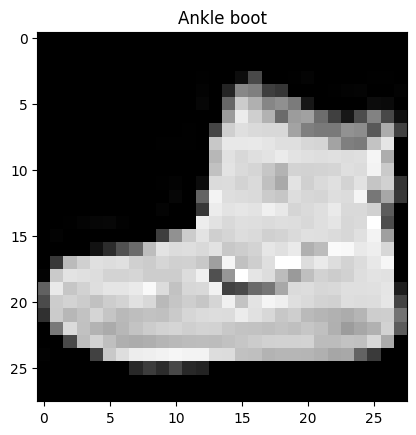

In [116]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(class_names[y_train[0]])
plt.show()

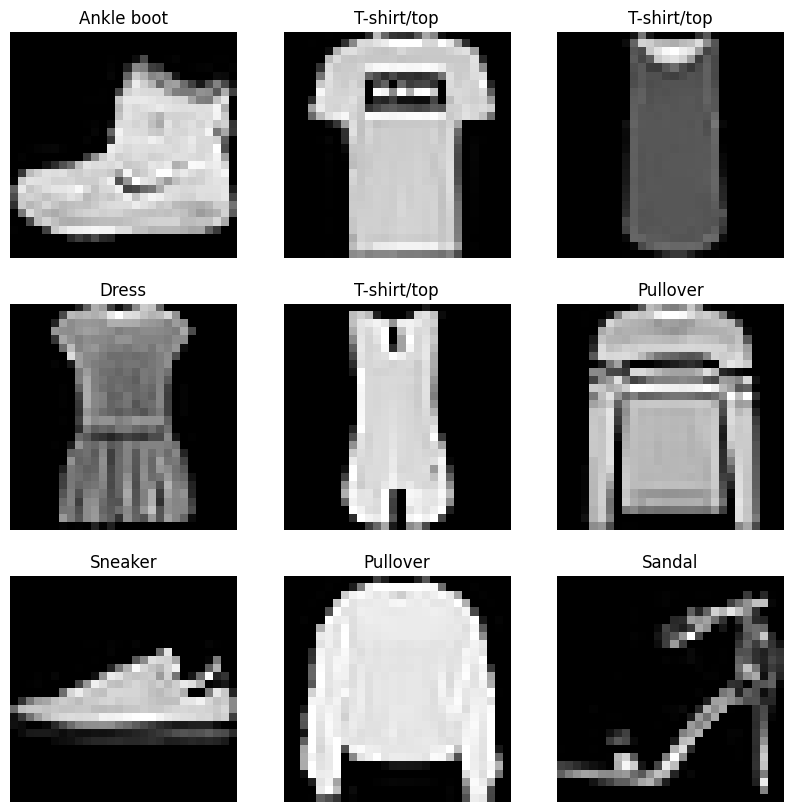

In [117]:



plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [118]:
X_train = X_train.reshape(-1,28,28,1).astype('float32')/255
X_test = X_test.reshape(-1,28,28,1).astype('float32')/255

In [119]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [120]:
cnn = models.Sequential([
    layers.Conv2D(32,(3,3), activation= "relu", input_shape = (28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation= "relu"),
    layers.Dense(10, activation = "softmax"),
])




In [121]:
cnn.compile(optimizer= 'adam',
            loss ="categorical_crossentropy",
            metrics  = ["accuracy"],
            )

In [124]:
cnn.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1)
# cnn.fit(X_train,y_train, batch_size = 64, epochs = 5,validation_split = 0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9254 - loss: 0.2028 - val_accuracy: 0.9117 - val_loss: 0.2456
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9331 - loss: 0.1820 - val_accuracy: 0.9178 - val_loss: 0.2265
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9387 - loss: 0.1658 - val_accuracy: 0.9080 - val_loss: 0.2585
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9452 - loss: 0.1482 - val_accuracy: 0.9172 - val_loss: 0.2291
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9513 - loss: 0.1312 - val_accuracy: 0.9222 - val_loss: 0.2405
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9561 - loss: 0.1187 - val_accuracy: 0.9173 - val_loss: 0.2377
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9612 - loss: 0.1064 - val_accuracy: 0.9197 - val_loss: 0.2389
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9652 - loss: 0.0951 - val_accuracy: 0.

In [134]:
test_loss, test_accuracy = cnn.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9083 - loss: 0.4373
Test Accuracy: 0.90829998254776


In [130]:
prediction = cnn.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [127]:
prediction_main = np.argmax(prediction,axis = 1)

In [132]:
print("Predicted:", prediction_main[0])
print("Actual:", y_test[0])

Predicted: 9
Actual: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
